In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
data = pd.read_csv("/content/Student_Feedback.csv")

data.head()

,Feedback_ID,Department,Subject,Rating,Feedback
0,1,CSE,Python,4,The classroom activities are engaging and help...
1,2,ECE,Signals and Systems,4,The subject is easy to understand because of p...
2,3,CIVIL,Construction Management,1,There are not enough practical sessions for th...
3,4,ECE,Signals and Systems,4,The teacher explains concepts clearly and make...
4,5,CIVIL,Surveying,4,The teacher encourages students to ask questions.


In [4]:
print("Rows and Columns:", data.shape)

Rows and Columns: (1000, 5)


In [5]:
  print("\nColumns:")
print(data.columns)


Columns:
Index(['Feedback_ID', 'Department', 'Subject', 'Rating', 'Feedback'], dtype='object')


In [6]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Feedback_ID    0
Department     0
Subject        0
Rating         0
Feedback       0
dtype: int64


In [7]:
print(data['Rating'].value_counts().sort_index())

Rating
1     91
2    121
3    263
4    302
5    223
Name: count, dtype: int64


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [10]:
data['Clean_Feedback'] = data['Feedback'].apply(clean_text)

data[['Feedback', 'Clean_Feedback']].head()

,Feedback,Clean_Feedback
0,The classroom activities are engaging and help...,classroom activity engaging helpful learning
1,The subject is easy to understand because of p...,subject easy understand practical example
2,There are not enough practical sessions for th...,enough practical session subject
3,The teacher explains concepts clearly and make...,teacher explains concept clearly make class in...
4,The teacher encourages students to ask questions.,teacher encourages student ask question


In [11]:
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [12]:
data['Sentiment'] = data['Clean_Feedback'].apply(get_sentiment)

data[['Feedback', 'Sentiment']].head()

,Feedback,Sentiment
0,The classroom activities are engaging and help...,Positive
1,The subject is easy to understand because of p...,Positive
2,There are not enough practical sessions for th...,Negative
3,The teacher explains concepts clearly and make...,Positive
4,The teacher encourages students to ask questions.,Neutral


In [13]:
print(data['Sentiment'].value_counts())

Sentiment
Positive    598
Neutral     244
Negative    158
Name: count, dtype: int64


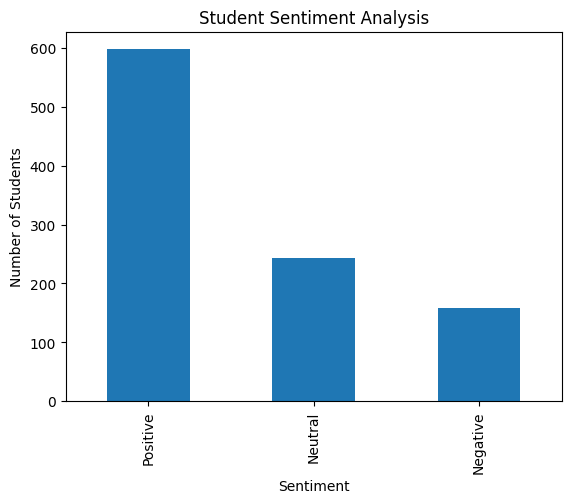

In [14]:
data['Sentiment'].value_counts().plot(kind='bar')

plt.title("Student Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")

plt.show()

In [15]:
concerns = [
    "teaching",
    "practical",
    "assignment",
    "material",
    "exam",
    "activity",
    "faculty",
    "explanation",
    "class",
    "subject"
]

In [16]:
concern_count = {}

for word in concerns:
    concern_count[word] = data['Clean_Feedback'].str.contains(
        word, case=False
    ).sum()

print(concern_count)

{'teaching': np.int64(123), 'practical': np.int64(216), 'assignment': np.int64(28), 'material': np.int64(116), 'exam': np.int64(137), 'activity': np.int64(144), 'faculty': np.int64(107), 'explanation': np.int64(54), 'class': np.int64(259), 'subject': np.int64(215)}


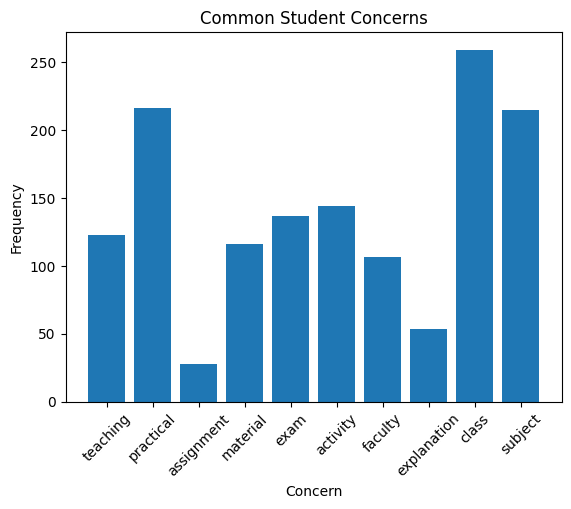

In [17]:
plt.bar(
    concern_count.keys(),
    concern_count.values()
)

plt.title("Common Student Concerns")
plt.xlabel("Concern")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [18]:
tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(data['Clean_Feedback'])

words = tfidf.get_feature_names_out()

scores = X.toarray().sum(axis=0)

result = pd.DataFrame({
    'Word': words,
    'Score': scores
})

result = result.sort_values(
    'Score',
    ascending=False
)

print(result)

           Word       Score
14      subject  112.759443
16     teaching  104.179824
0      activity   98.436296
2     classroom   98.436296
11    practical   96.701447
15      teacher   90.537332
3       concept   87.568960
6       faculty   76.731873
7   interesting   75.424429
10         need   72.302037
4          easy   70.691856
17   understand   69.664437
18       useful   68.883311
19         well   67.781918
1         class   64.119060
9      material   63.518947
13        study   63.518947
5       example   61.734571
12      session   61.305567
8       lecture   60.848654


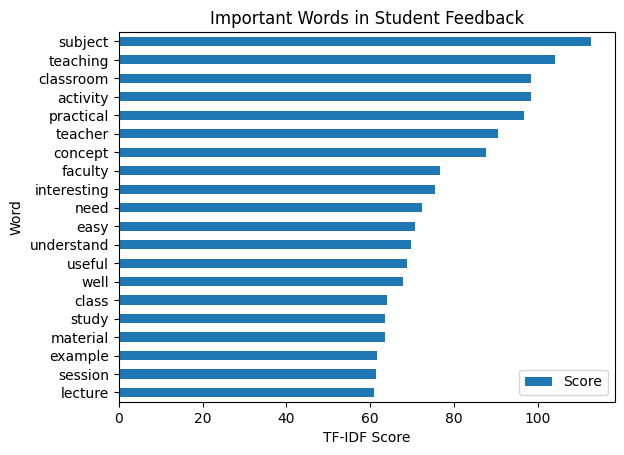

In [19]:
result.sort_values('Score').plot(
    x='Word',
    y='Score',
    kind='barh'
)

plt.title("Important Words in Student Feedback")
plt.xlabel("TF-IDF Score")

plt.show()

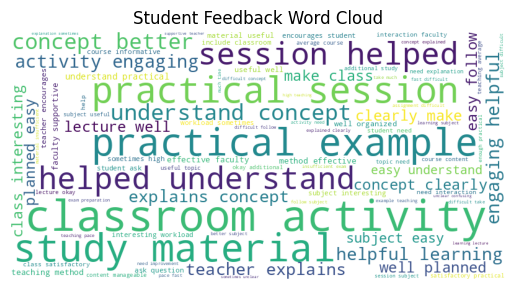

In [20]:
text = " ".join(data['Clean_Feedback'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Student Feedback Word Cloud")

plt.show()

In [21]:
sorted_concerns = sorted(
    concern_count.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Common Concerns:")
print(sorted_concerns)

Common Concerns:
[('class', np.int64(259)), ('practical', np.int64(216)), ('subject', np.int64(215)), ('activity', np.int64(144)), ('exam', np.int64(137)), ('teaching', np.int64(123)), ('material', np.int64(116)), ('faculty', np.int64(107)), ('explanation', np.int64(54)), ('assignment', np.int64(28))]


In [24]:
print("STUDENT FEEDBACK IMPROVEMENT SUGGESTIONS")

print("1. Increase practical and hands-on sessions.")

print("2. Provide better study materials.")

print("3. Improve explanation of difficult concepts.")

print("4. Include more classroom activities.")

print("5. Provide additional support for difficult subjects.")

print("6. Encourage more interaction between students and faculty.")

print("7. Review assignment difficulty and workload.")

STUDENT FEEDBACK IMPROVEMENT SUGGESTIONS
1. Increase practical and hands-on sessions.
2. Provide better study materials.
3. Improve explanation of difficult concepts.
4. Include more classroom activities.
5. Provide additional support for difficult subjects.
6. Encourage more interaction between students and faculty.
7. Review assignment difficulty and workload.


In [25]:
print("STUDENT FEEDBACK ANALYSIS REPORT")
print("Total Feedback:", len(data))

print("\nAverage Rating:",
      round(data['Rating'].mean(), 2))

print("\nSentiment Distribution:")
print(data['Sentiment'].value_counts())

print("\nDepartment-wise Feedback:")
print(data['Department'].value_counts())

print("\nMost Common Concerns:")

for word, count in sorted_concerns[:5]:
    print(word, ":", count)

STUDENT FEEDBACK ANALYSIS REPORT
Total Feedback: 1000

Average Rating: 3.44

Sentiment Distribution:
Sentiment
Positive    598
Neutral     244
Negative    158
Name: count, dtype: int64

Department-wise Feedback:
Department
EEE      214
ECE      207
MECH     204
CSE      195
CIVIL    180
Name: count, dtype: int64

Most Common Concerns:
class : 259
practical : 216
subject : 215
activity : 144
exam : 137
